In [1]:
# Import Required Libraries

import arcpy
import pandas as pd
import matplotlib.pyplot as plt
from arcpy.sa import *

print(arcpy.__version__)

3.5


In [2]:
# Enable Spatial Analyst

arcpy.CheckOutExtension("Spatial")

'CheckedOut'

In [3]:
# Define Your Inputs
# For each updated automation of this notebook, change "landuse_raster" and "boundary_fc". 

year = 2024

landuse_raster = r"C:\Users\User\Documents\Bootcamp GIS Certification\5_Setup AWS map services for wildfire assessments\Assignment 10\Uwharrie NF Capstone\Land Cover Data\UwharrieNF_LandCover.tif"

boundary_fc = r"C:\Users\User\Documents\Bootcamp GIS Certification\5_Setup AWS map services for wildfire assessments\Assignment 10\Uwharrie NF Capstone\Uwharrie NF Land Cover\Uwharries_Boundary.lyrx"

output_folder = r"C:\Users\User\Documents\Bootcamp GIS Certification\5_Setup AWS map services for wildfire assessments\Assignment 10\Uwharrie NF Capstone"

In [4]:
# Set Workspace

arcpy.env.workspace = output_folder
arcpy.env.overwriteOutput = True

In [5]:
# Clip the Land Use Raster

clipped_raster = f"{output_folder}/landuse_clip_{year}.tif"

arcpy.Clip_management(
    landuse_raster,
    "#",
    clipped_raster,
    boundary_fc,
    "#",
    "ClippingGeometry"
)

<Result 'C:\\Users\\User\\Documents\\Bootcamp GIS Certification\\5_Setup AWS map services for wildfire assessments\\Assignment 10\\Uwharrie NF Capstone\\landuse_clip_2024.tif'>

In [6]:
# Find a field in the attribute table that has data for every data point (like OBJECTID or FID)

fields = [f.name for f in arcpy.ListFields(boundary_fc)]
print(fields)

['FID', 'ADMINFORES', 'REGION', 'FORESTNUMB', 'FORESTORGC', 'FORESTNAME', 'GIS_ACRES', 'SHAPE_AREA', 'SHAPE_LEN', 'Shape__Area', 'Shape__Length', 'Shape']


In [7]:
# Calculate Area per Land Use using the FID field

table_output = f"{output_folder}/landuse_area_{year}.dbf"

TabulateArea(
    boundary_fc,
    "FID",
    clipped_raster,
    "Value",
    table_output
)

<Result 'C:\\Users\\User\\Documents\\Bootcamp GIS Certification\\5_Setup AWS map services for wildfire assessments\\Assignment 10\\Uwharrie NF Capstone\\landuse_area_2024.dbf'>

In [8]:
# Convert Table to a Pandas DataFrame

arr = arcpy.da.TableToNumPyArray(table_output, "*")
df = pd.DataFrame(arr)

df

,OID,FID_,VALUE_11,VALUE_21,VALUE_22,VALUE_23,VALUE_24,VALUE_31,VALUE_41,VALUE_42,VALUE_43,VALUE_52,VALUE_71,VALUE_81,VALUE_82,VALUE_90,VALUE_95
0,0,1,2449800.0,43425900.0,13314600.0,3184200.0,865800.0,2064600.0,303134400.0,261189000.0,115657200.0,38649600.0,44599500.0,50006700.0,5646600.0,4887900.0,79200.0


In [9]:
#  Convert pixels to acres

pixel_area_m2 = 30 * 30
acre_conversion = 4046.86

for col in df.columns:
    if "VALUE_" in col:
        df[col] = (df[col] * pixel_area_m2) / acre_conversion

df

,OID,FID_,VALUE_11,VALUE_21,VALUE_22,VALUE_23,VALUE_24,VALUE_31,VALUE_41,VALUE_42,VALUE_43,VALUE_52,VALUE_71,VALUE_81,VALUE_82,VALUE_90,VALUE_95
0,0,1,544822.405519,9.657688e+06,2.961096e+06,708149.034066,192549.285125,459155.987605,6.741547e+07,5.808704e+07,2.572154e+07,8.595464e+06,9.918690e+06,1.112122e+07,1.255774e+06,1.087043e+06,17613.65602


In [10]:
# Calculate Percentages

total_acres = df.filter(like="VALUE_").sum(axis=1)

percent_df = df.filter(like="VALUE_").div(total_acres, axis=0) * 100

percent_df

,VALUE_11,VALUE_21,VALUE_22,VALUE_23,VALUE_24,VALUE_31,VALUE_41,VALUE_42,VALUE_43,VALUE_52,VALUE_71,VALUE_81,VALUE_82,VALUE_90,VALUE_95
0,0.27552,4.883952,1.497444,0.358115,0.097373,0.232198,34.092414,29.374968,13.007541,4.346779,5.015942,5.62407,0.635052,0.549724,0.008907


In [11]:
# Create a Summary Table

summary = pd.DataFrame({
    "LandUse": df.filter(like="VALUE_").columns,
    "Acres": df.filter(like="VALUE_").iloc[0].values,
    "Percent": percent_df.iloc[0].values
})

summary

,LandUse,Acres,Percent
0,VALUE_11,5.448224e+05,0.275520
1,VALUE_21,9.657688e+06,4.883952
2,VALUE_22,2.961096e+06,1.497444
3,VALUE_23,7.081490e+05,0.358115
4,VALUE_24,1.925493e+05,0.097373
5,VALUE_31,4.591560e+05,0.232198
6,VALUE_41,6.741547e+07,34.092414
7,VALUE_42,5.808704e+07,29.374968
8,VALUE_43,2.572154e+07,13.007541
9,VALUE_52,8.595464e+06,4.346779


In [12]:
# Create readable land use labels
# Combine multiple fields into one

landuse_labels = {
    "VALUE_11": "Open Water",
    "VALUE_21": "Developed",
    "VALUE_22": "Developed",
    "VALUE_23": "Developed",
    "VALUE_24": "Developed",
    "VALUE_31": "Other",
    "VALUE_41": "Deciduous Forest",
    "VALUE_42": "Evergreen Forest",
    "VALUE_43": "Deciduous Forest",
    "VALUE_52": "Grassland/Scrub Shrub",
    "VALUE_71": "Grassland/Scrub Shrub",
    "VALUE_81": "Farmland",
    "VALUE_82": "Farmland",
    "VALUE_90": "Wetlands",
    "VALUE_95": "Wetlands"
}

summary = pd.DataFrame({
    "LandUse": df.filter(like="VALUE_").columns,
    "Acres": df.filter(like="VALUE_").iloc[0].values,
    "Percent": percent_df.iloc[0].values
})

summary["LandUse"] = summary["LandUse"].map(landuse_labels)

# Combine developed classes
summary = summary.groupby("LandUse", as_index=False).sum()

# Reduce decimal places / round numbers for easier readability 
summary["Acres"] = summary["Acres"].round(0)
summary["Percent"] = summary["Percent"].round(2)

# SORT largest to smallest
summary = summary.sort_values(by="Acres", ascending=False)

summary

,LandUse,Acres,Percent
0,Deciduous Forest,93137010.0,47.10
2,Evergreen Forest,58087035.0,29.37
4,Grassland/Scrub Shrub,18514154.0,9.36
1,Developed,13519482.0,6.84
3,Farmland,12376996.0,6.26
7,Wetlands,1104656.0,0.56
5,Open Water,544822.0,0.28
6,Other,459156.0,0.23


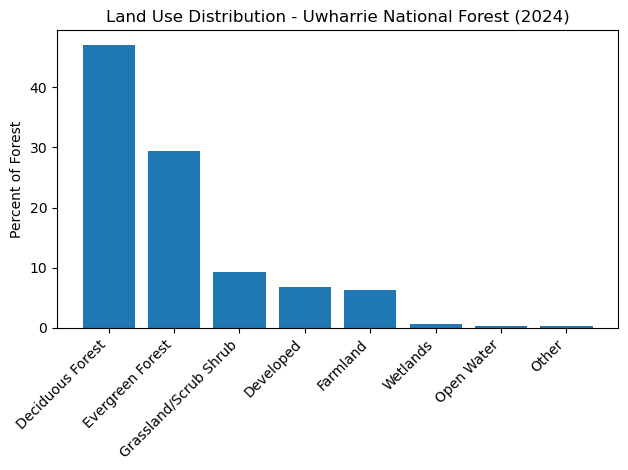

In [13]:
# Create the Chart

plt.figure()

plt.bar(summary["LandUse"], summary["Percent"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Percent of Forest")

plt.title(f"Land Use Distribution - Uwharrie National Forest ({year})")

plt.tight_layout()

plt.show()

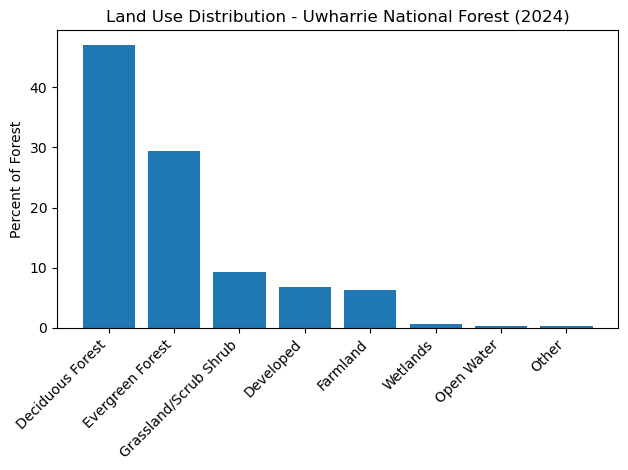

In [14]:
# Save the Table
summary.to_csv(f"{output_folder}/landuse_summary_{year}.csv", index=False)

#Save the Chart
plt.figure()

plt.bar(summary["LandUse"], summary["Percent"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Percent of Forest")

plt.title(f"Land Use Distribution - Uwharrie National Forest ({year})")

plt.tight_layout()

plt.savefig(f"{output_folder}/landuse_chart_{year}.png")